In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\uebne\\Desktop\\Bootcamp\\Apuntes_Eduardo\\2-Data_analysis\\3-Machine_Learning\\Proyecto_M_L_Eduardo\\Data\\raw\\inventory_demand_stockout_risk.csv')

print(df.head())        
print(df.info())        
print(df.describe())

  product_id        date store_id  current_stock  daily_demand  \
0      P1000  2024-01-01       S7            213           114   
1      P1001  2024-01-02      S20            152            87   
2      P1002  2024-01-03      S15            209            62   
3      P1003  2024-01-04      S11            400           103   
4      P1004  2024-01-05       S8             60           114   

   lead_time_days  supplier_reliability_score promotion_active weather_impact  \
0               5                          72               No         Medium   
1               7                          84               No           High   
2              10                          61               No            Low   
3              10                          61               No            Low   
4               9                          75               No         Medium   

  stockout_risk  
0            No  
1           Yes  
2            No  
3            No  
4            No  
<class '

In [10]:
df['stockout_risk'].value_counts()

print("\n--- Demanda media según riesgo ---")
print(df.groupby('stockout_risk')['daily_demand'].mean())


--- Demanda media según riesgo ---
stockout_risk
0    61.711374
1    62.581159
Name: daily_demand, dtype: float64


La demanda por sí sola no predice la rotura de stock. Si el modelo solo mirara la cantidad demandada, no sabría distinguir entre un caso de riesgo y uno que no lo es. El modelo va a necesitar aprender de la combinación de todas las variables (stock actual, fiabilidad del proveedor, promociones, etc.). Aparece luego en el heatmap para todas las variables.

In [3]:
# Convertir columnas binarias
df['stockout_risk'] = df['stockout_risk'].map({'No': 0, 'Yes': 1})
df['promotion_active'] = df['promotion_active'].map({'No': 0, 'Yes': 1})

# Convertir variables con más categorías (como clima) a columnas separadas
df = pd.get_dummies(df, columns=['weather_impact'], drop_first=True)

In [4]:
# Ver si hay celdas vacías
print(df.isnull().sum())

# Si hay nulos, o los borramos o los rellenamos si hay muchos. Los borramos.
df = df.dropna()

product_id                    0
date                          0
store_id                      0
current_stock                 0
daily_demand                  0
lead_time_days                0
supplier_reliability_score    0
promotion_active              0
stockout_risk                 0
weather_impact_Low            0
weather_impact_Medium         0
dtype: int64


In [5]:
# Eliminar filas idénticas
df = df.drop_duplicates()

In [6]:
# Quitamos las columnas que no aportan información predictiva al modelo
df_model = df.drop(columns=['date', 'product_id', 'store_id'])

# Guardamos el archivo final
df_model.to_csv('../data/processed/inventory_ready_for_model.csv', index=False)
print("Archivo limpio en data/processed/inventory_ready_for_model.csv")

Archivo limpio en data/processed/inventory_ready_for_model.csv


Hacemos un heatmap y un pairplot

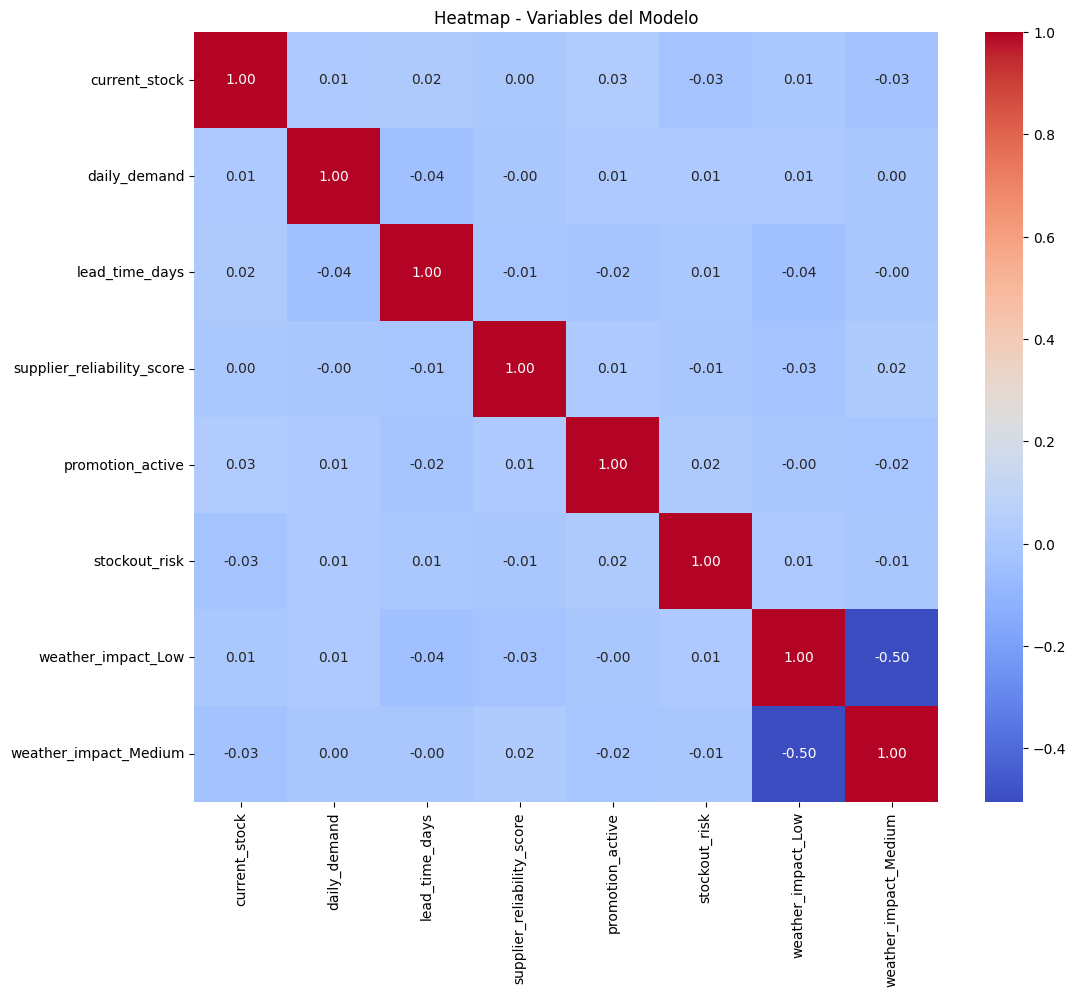

In [7]:
plt.figure(figsize=(12, 10))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")

plt.title('Heatmap - Variables del Modelo')
plt.show()

Todas tienen muy poca correlacion, salvo el weather impact

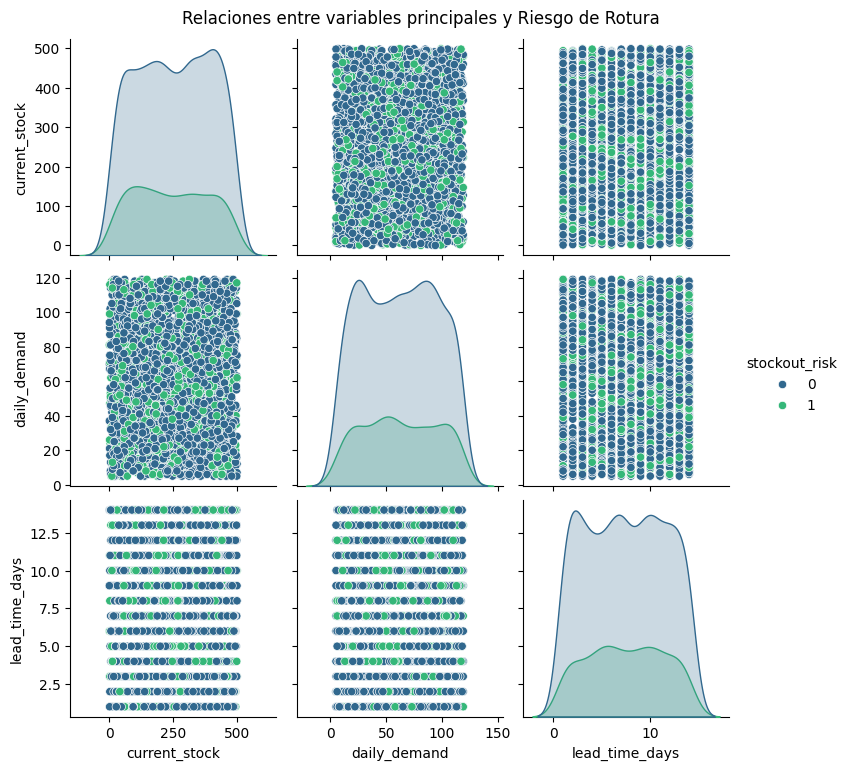

In [ ]:
columnas_interes = ['current_stock', 'daily_demand', 'lead_time_days', 'stockout_risk']

sns.pairplot(df[columnas_interes], hue='stockout_risk', palette='viridis', diag_kind='kde')

plt.suptitle('Relaciones entre variables principales y Riesgo de Rotura', y=1.02)
plt.show()